In [6]:
import pandas as pd
import pandas_ta as ta

df = pd.read_csv("../../data/MSFT.USUSD_Candlestick_5_M_BID_01.09.2022-21.09.2024.csv")
df=df[0:5000]
df=df[df['Volume']!=0]
df["Gmt time"]=df["Gmt time"].str.replace(".000","")
df['Gmt time']=pd.to_datetime(df['Gmt time'],format='%d.%m.%Y %H:%M:%S')

## Take the rolling atr so the yaxis doesn't shake too much 
df["atr"] = ta.atr(high=df.High, low=df.Low, close=df.Close)
df["atr"] = df.atr.rolling(window=30).mean()

df.reset_index(drop=True, inplace=True)

df

,Gmt time,Open,High,Low,Close,Volume,atr
0,2022-09-01 13:30:00,259.337,259.547,257.896,257.927,2.0268,NaN
1,2022-09-01 13:35:00,257.967,258.957,257.926,258.576,2.2260,NaN
2,2022-09-01 13:40:00,258.547,259.377,258.396,258.737,2.2716,NaN
3,2022-09-01 13:45:00,258.687,259.277,258.466,258.766,2.7444,NaN
4,2022-09-01 13:50:00,258.726,259.147,258.496,259.087,2.4504,NaN
...,...,...,...,...,...,...,...
845,2022-09-16 19:35:00,244.006,244.297,243.816,244.296,2.6388,0.499994
846,2022-09-16 19:40:00,244.306,244.577,244.096,244.397,2.8860,0.502256
847,2022-09-16 19:45:00,244.406,244.476,243.756,244.476,2.4084,0.505355
848,2022-09-16 19:50:00,244.427,245.016,244.206,244.747,2.3856,0.509136


In [2]:
%matplotlib inline

import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.signal import find_peaks
pd.set_option('mode.chained_assignment', None)

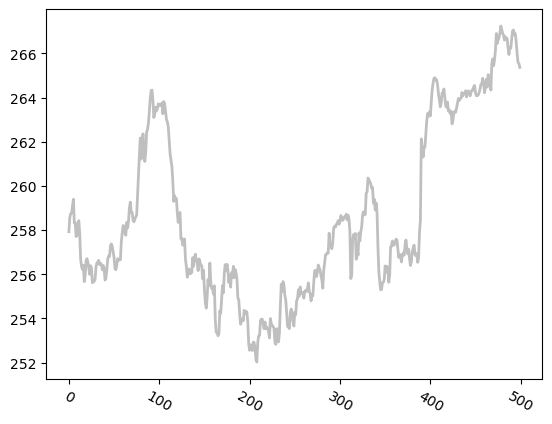

In [3]:
df2 = df.iloc[0:500]

fig, ax = plt.subplots()
plt.xticks(rotation=-30)
price, = ax.plot(df2.index, df2.Close, c='grey', lw=2, alpha=0.5, zorder=5)

plt.show()

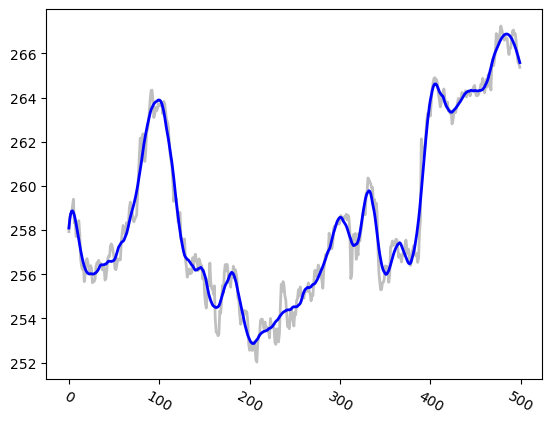

In [4]:
df2 = df.iloc[0:500]

df2["close_smooth"] = savgol_filter(df2.Close, 49, 5)

fig, ax = plt.subplots()
plt.xticks(rotation=-30)
price, = ax.plot(df2.index, df2.Close, c='grey', lw=2, alpha=0.5, zorder=5)
price_smooth, = ax.plot(df2.index, df2.close_smooth, c='b', lw=2, zorder=5)

plt.show()

[  4  99 180 301 332 366 405 484]
[ 27 163 204 315 351 377 423]


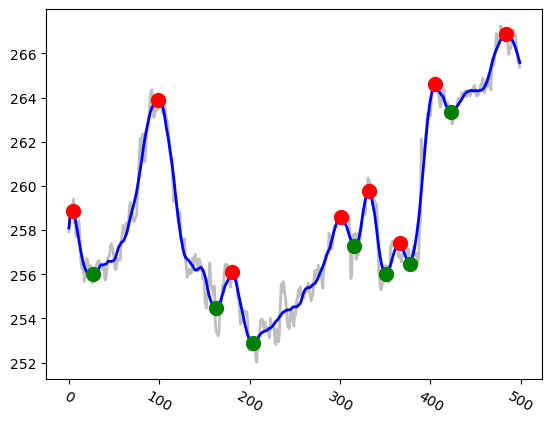

In [5]:
df2 = df.iloc[0:500]

df2["close_smooth"] = savgol_filter(df2.Close, 49, 5)

fig, ax = plt.subplots()
plt.xticks(rotation=-30)
price, = ax.plot(df2.index, df2.Close, c='grey', lw=2, alpha=0.5, zorder=5)
price_smooth, = ax.plot(df2.index, df2.close_smooth, c='b', lw=2, zorder=5)

atr = df2.atr.iloc[-1] # all the first atrs are NaN

peaks_idx, _ = find_peaks(df2.close_smooth, distance = 15, width = 3, prominence=atr)

print(peaks_idx)

troughs_idx, _ = find_peaks(-1*df2.close_smooth, distance = 15, width = 3, prominence=atr)

print(troughs_idx)

peaks, = ax.plot(df2.index[peaks_idx], df2.close_smooth.iloc[peaks_idx], \
                 c="r", linestyle='None', markersize = 10.0, marker = "o", zorder=10)

troughs, = ax.plot(df2.index[troughs_idx], df2.close_smooth.iloc[troughs_idx], \
                   c="g", linestyle='None', markersize = 10.0, marker = "o", zorder=10)

plt.show()

0


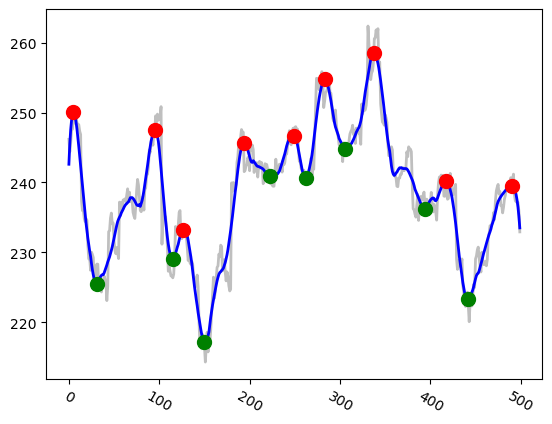

In [6]:
df2 = df.iloc[0:500]

df2["close_smooth"] = savgol_filter(df2.Close, 49, 5)

fig, ax = plt.subplots()
plt.xticks(rotation=-30)
plt.xticks(rotation=-30)
price, = ax.plot(df2.index, df2.Close, c='grey', lw=2, alpha=0.5, zorder=5)
price_smooth, = ax.plot(df2.index, df2.close_smooth, c='b', lw=2, zorder=5)

atr = df2.atr.iloc[-1] # all the first atrs are NaN

peaks_idx, _ = find_peaks(df2.close_smooth, distance = 15, width = 3, prominence=atr)

troughs_idx, _ = find_peaks(-1*df2.close_smooth, distance = 15,width = 3, prominence=atr)

peaks, = ax.plot(df2.index[peaks_idx], df2.close_smooth.iloc[peaks_idx], \
                 c="r", linestyle='None', markersize = 10.0, marker = "o", zorder=10)

troughs, = ax.plot(df2.index[troughs_idx], df2.close_smooth.iloc[troughs_idx], \
                   c="g", linestyle='None', markersize = 10.0, marker = "o", zorder=10)


up_run_length = 0
up_run = True
while up_run:
    if 2 + up_run_length > len(peaks_idx) or 2 + up_run_length > len(troughs_idx):
        break
        
    if df2.close_smooth.iloc[peaks_idx[-1 - up_run_length]] > df2.close_smooth.iloc[peaks_idx[-2 - up_run_length]] and \
       df2.close_smooth.iloc[troughs_idx[-1 - up_run_length]] > df2.close_smooth.iloc[troughs_idx[-2 - up_run_length]]:
        up_run_length += 1
    else:
        up_run = False    
          

if up_run_length > 0:
    ax.set_facecolor((150/255, 255/255, 159/255, 0.3))  
else:
    ax.set_facecolor("white")
        
print(up_run_length)

plt.show()